# 🏠 Projeto de Ciência de Dados: Previsão de Preços de Imóveis

Este notebook é um guia **passo a passo** para construir um projeto de Machine Learning do início ao fim, passando pelas etapas clássicas de um projeto de Ciência de Dados:

1. **Coleta de dados**
2. **Análise Exploratória de Dados (EDA)**
3. **Pré-processamento dos dados**
4. **Modelagem (treinamento dos modelos)**
5. **Avaliação dos modelos**
6. **Teste com dados novos**
7. **Exportação de uma planilha com as previsões**

**Objetivo:** prever o preço de venda de imóveis com base em características como área, número de quartos, banheiros, idade do imóvel, distância do centro e bairro.

> 💡 Este notebook usa um **dataset sintético** (gerado artificialmente, mas de forma realista) para que qualquer pessoa consiga executar o notebook sem precisar baixar arquivos externos. O fluxo de trabalho é exatamente o mesmo que você usaria com dados reais.

## 1️⃣ Importação das bibliotecas

Aqui importamos todas as ferramentas que vamos usar ao longo do projeto.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configurações visuais
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Semente para resultados reprodutíveis
np.random.seed(42)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2️⃣ Etapa 1 — Coleta de Dados

Em um projeto real, os dados normalmente vêm de um arquivo CSV, um banco de dados ou uma API, por exemplo:

```python
df = pd.read_csv("meus_dados.csv")
```

Para este notebook, vamos **gerar um dataset sintético** de imóveis, simulando informações realistas. Isso permite que o notebook seja executado por qualquer pessoa, sem depender de arquivos externos.

In [2]:
n_amostras = 500

bairros = ["Centro", "Zona Sul", "Zona Norte", "Periferia"]
peso_bairro = {"Centro": 1.35, "Zona Sul": 1.5, "Zona Norte": 1.05, "Periferia": 0.75}

area_m2 = np.random.normal(90, 30, n_amostras).clip(30, 250)
quartos = np.random.randint(1, 5, n_amostras)
banheiros = np.random.randint(1, 4, n_amostras)
idade_anos = np.random.randint(0, 40, n_amostras)
distancia_centro_km = np.random.uniform(0.5, 25, n_amostras)
garagem = np.random.randint(0, 2, n_amostras)
bairro = np.random.choice(bairros, n_amostras)

fator_bairro = np.array([peso_bairro[b] for b in bairro])

# Fórmula "realista" de preço + ruído aleatório
preco = (
    area_m2 * 3800
    + quartos * 15000
    + banheiros * 9000
    + garagem * 12000
    - idade_anos * 1800
    - distancia_centro_km * 2500
) * fator_bairro

preco = preco + np.random.normal(0, 25000, n_amostras)
preco = preco.clip(60000, None).round(2)

df = pd.DataFrame({
    "area_m2": area_m2.round(1),
    "quartos": quartos,
    "banheiros": banheiros,
    "idade_anos": idade_anos,
    "distancia_centro_km": distancia_centro_km.round(2),
    "garagem": garagem,
    "bairro": bairro,
    "preco": preco
})

print(f"Dataset criado com {df.shape[0]} imóveis e {df.shape[1]} colunas.")
df.head()

Dataset criado com 500 imóveis e 8 colunas.


,area_m2,quartos,banheiros,idade_anos,distancia_centro_km,garagem,bairro,preco
0,104.9,2,2,0,16.06,0,Centro,553373.88
1,85.9,4,3,37,18.99,0,Zona Norte,325622.25
2,109.4,2,2,14,4.68,1,Centro,611027.38
3,135.7,3,3,33,10.53,0,Centro,680330.33
4,83.0,4,3,34,10.86,1,Zona Sul,500488.02


## 3️⃣ Etapa 2 — Análise Exploratória de Dados (EDA)

Antes de treinar qualquer modelo, precisamos **entender os dados**: quais são os tipos de cada coluna, se há valores ausentes, qual a distribuição das variáveis e como elas se relacionam com o preço.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   area_m2              500 non-null    float64
 1   quartos              500 non-null    int64  
 2   banheiros            500 non-null    int64  
 3   idade_anos           500 non-null    int64  
 4   distancia_centro_km  500 non-null    float64
 5   garagem              500 non-null    int64  
 6   bairro               500 non-null    str    
 7   preco                500 non-null    float64
dtypes: float64(3), int64(4), str(1)
memory usage: 31.4 KB


In [4]:
df.describe()

,area_m2,quartos,banheiros,idade_anos,distancia_centro_km,garagem,preco
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,5.000000e+02
mean,90.350000,2.488000,1.976000,19.074000,12.437500,0.472000,3.935719e+05
std,29.076018,1.101036,0.820225,11.544135,7.050277,0.499715,1.690721e+05
min,30.000000,1.000000,1.000000,0.000000,0.510000,0.000000,6.000000e+04
25%,68.975000,2.000000,1.000000,9.000000,6.067500,0.000000,2.725156e+05
50%,90.400000,3.000000,2.000000,19.000000,12.415000,0.000000,3.759872e+05
75%,109.100000,3.000000,3.000000,29.000000,18.780000,1.000000,4.951328e+05
max,205.600000,4.000000,3.000000,39.000000,24.810000,1.000000,1.138282e+06


In [5]:
# Verificando valores ausentes
df.isnull().sum()

area_m2                0
quartos                0
banheiros              0
idade_anos             0
distancia_centro_km    0
garagem                0
bairro                 0
preco                  0
dtype: int64

### Distribuição das variáveis numéricas

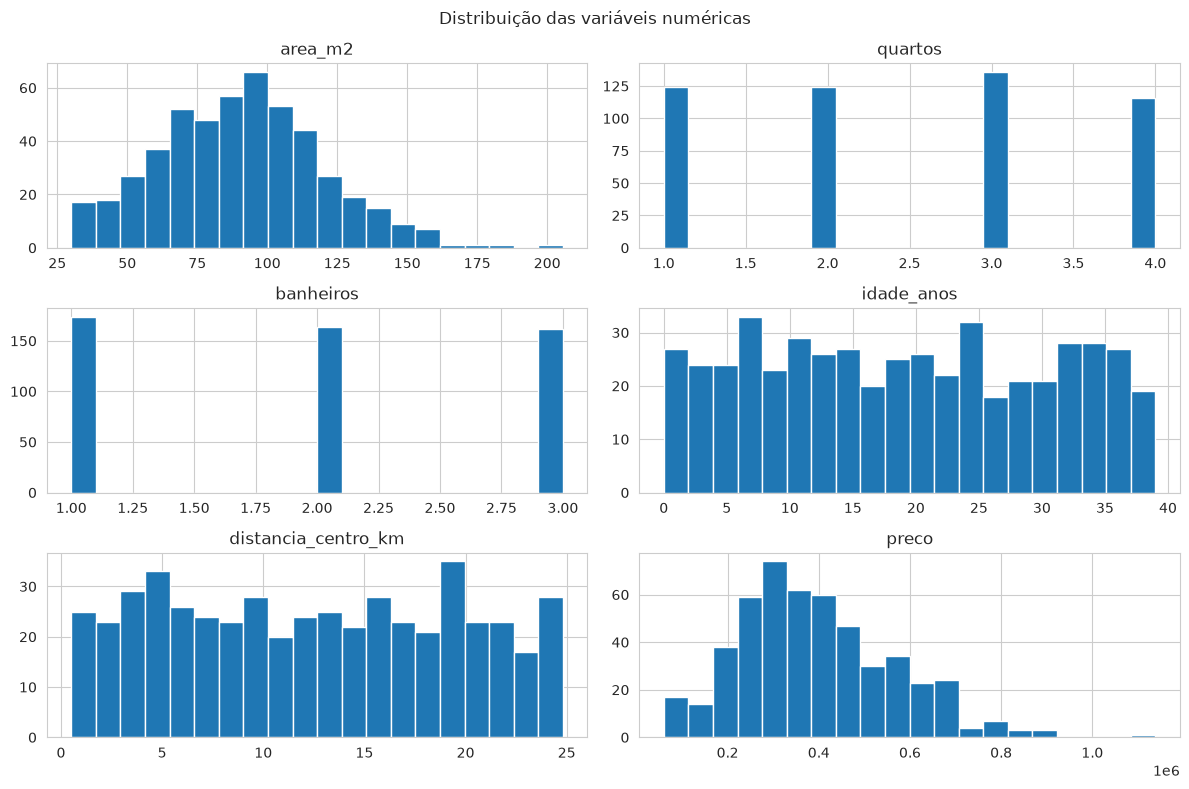

In [6]:
colunas_numericas = ["area_m2", "quartos", "banheiros", "idade_anos", "distancia_centro_km", "preco"]

df[colunas_numericas].hist(bins=20, figsize=(12, 8))
plt.suptitle("Distribuição das variáveis numéricas")
plt.tight_layout()
plt.show()

### Correlação entre as variáveis numéricas e o preço

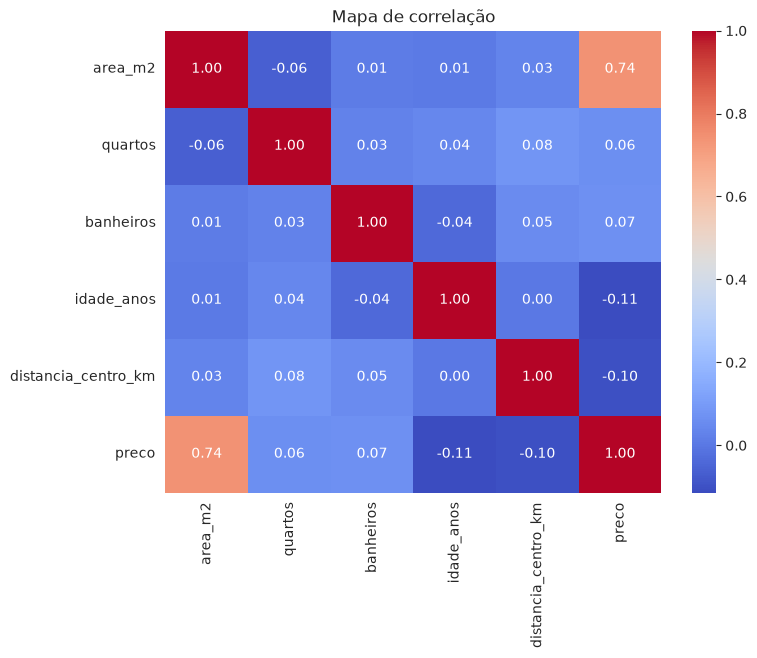

In [7]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[colunas_numericas].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Mapa de correlação")
plt.show()

### Preço médio por bairro

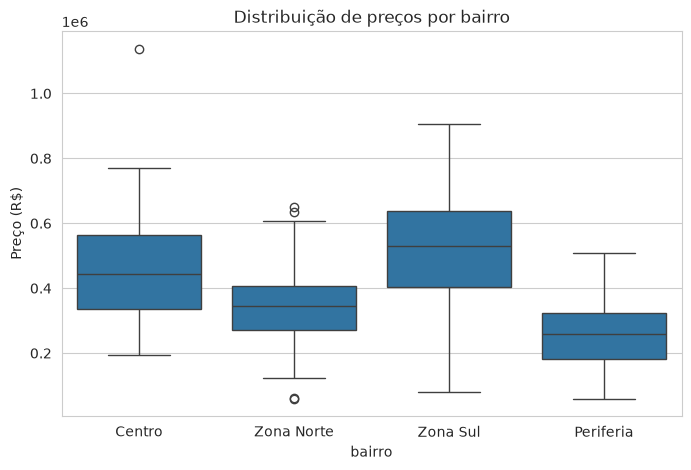

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="bairro", y="preco")
plt.title("Distribuição de preços por bairro")
plt.ylabel("Preço (R$)")
plt.show()

### Relação entre área do imóvel e preço

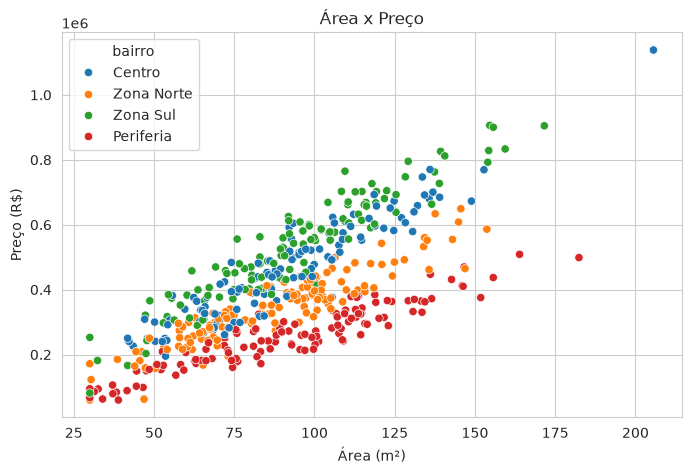

In [9]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x="area_m2", y="preco", hue="bairro")
plt.title("Área x Preço")
plt.xlabel("Área (m²)")
plt.ylabel("Preço (R$)")
plt.show()

## 4️⃣ Etapa 3 — Pré-processamento dos Dados

Nesta etapa preparamos os dados para o modelo de Machine Learning:

- Tratamos valores ausentes (se houver)
- Transformamos a variável categórica `bairro` em números (**One-Hot Encoding**)
- Separamos as variáveis independentes (`X`) da variável alvo (`y`)
- Dividimos os dados em **treino** e **teste**
- Padronizamos as variáveis numéricas (importante para a Regressão Linear)

In [10]:
# Caso existissem valores ausentes, poderíamos tratá-los assim (exemplo ilustrativo):
# df["area_m2"] = df["area_m2"].fillna(df["area_m2"].median())

# Transformando a variável categórica 'bairro' em colunas binárias (one-hot encoding)
df_processado = pd.get_dummies(df, columns=["bairro"], drop_first=True)
df_processado.head()

,area_m2,quartos,banheiros,idade_anos,distancia_centro_km,garagem,preco,bairro_Periferia,bairro_Zona Norte,bairro_Zona Sul
0,104.9,2,2,0,16.06,0,553373.88,False,False,False
1,85.9,4,3,37,18.99,0,325622.25,False,True,False
2,109.4,2,2,14,4.68,1,611027.38,False,False,False
3,135.7,3,3,33,10.53,0,680330.33,False,False,False
4,83.0,4,3,34,10.86,1,500488.02,False,False,True


In [11]:
# Separando variáveis independentes (X) e variável alvo (y)
X = df_processado.drop(columns=["preco"])
y = df_processado["preco"]

# Dividindo em treino (80%) e teste (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Tamanho do treino: {X_train.shape[0]} imóveis")
print(f"Tamanho do teste:  {X_test.shape[0]} imóveis")

Tamanho do treino: 400 imóveis
Tamanho do teste:  100 imóveis


In [12]:
# Padronização das variáveis (média 0, desvio padrão 1)
# Necessária para a Regressão Linear funcionar bem; modelos baseados em árvores não precisam disso.
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Dados padronizados com sucesso!")

Dados padronizados com sucesso!


## 5️⃣ Etapa 4 — Modelagem (Treinamento dos Modelos)

Vamos treinar **dois modelos** diferentes e depois comparar o desempenho de cada um:

1. **Regressão Linear** — modelo simples, ótimo para começar.
2. **Random Forest Regressor** — modelo mais robusto, que geralmente captura relações não-lineares.

In [13]:
# Modelo 1: Regressão Linear
modelo_lr = LinearRegression()
modelo_lr.fit(X_train_scaled, y_train)

previsoes_lr = modelo_lr.predict(X_test_scaled)

print("Regressão Linear treinada com sucesso!")

Regressão Linear treinada com sucesso!


In [14]:
# Modelo 2: Random Forest Regressor
modelo_rf = RandomForestRegressor(n_estimators=200, random_state=42)
modelo_rf.fit(X_train, y_train)

previsoes_rf = modelo_rf.predict(X_test)

print("Random Forest treinado com sucesso!")

Random Forest treinado com sucesso!


## 6️⃣ Etapa 5 — Avaliação dos Modelos

Para saber qual modelo é melhor, usamos métricas de erro:

- **MAE** (Erro Absoluto Médio): quanto, em média, o modelo erra em R$.
- **RMSE** (Raiz do Erro Quadrático Médio): penaliza mais os erros grandes.
- **R²**: o quanto o modelo consegue explicar a variação dos preços (quanto mais perto de 1, melhor).

In [15]:
def avaliar_modelo(y_real, y_previsto, nome_modelo):
    mae = mean_absolute_error(y_real, y_previsto)
    rmse = np.sqrt(mean_squared_error(y_real, y_previsto))
    r2 = r2_score(y_real, y_previsto)
    return {"Modelo": nome_modelo, "MAE (R$)": mae, "RMSE (R$)": rmse, "R²": r2}

resultados = pd.DataFrame([
    avaliar_modelo(y_test, previsoes_lr, "Regressão Linear"),
    avaliar_modelo(y_test, previsoes_rf, "Random Forest"),
])

resultados = resultados.round(2)
resultados

,Modelo,MAE (R$),RMSE (R$),R²
0,Regressão Linear,35246.74,43412.37,0.95
1,Random Forest,35940.86,55193.37,0.91


### Escolhendo o modelo final

Em vez de assumir de antemão qual algoritmo é "melhor", vamos deixar os **dados decidirem**: escolhemos automaticamente o modelo com o **menor RMSE** no conjunto de teste.

In [16]:
linha_lr = resultados.loc[resultados["Modelo"] == "Regressão Linear"].iloc[0]
linha_rf = resultados.loc[resultados["Modelo"] == "Random Forest"].iloc[0]

if linha_rf["RMSE (R$)"] < linha_lr["RMSE (R$)"]:
    modelo_final = modelo_rf
    X_test_final = X_test
    previsoes_final = previsoes_rf
    nome_modelo_final = "Random Forest"
else:
    modelo_final = modelo_lr
    X_test_final = X_test_scaled
    previsoes_final = previsoes_lr
    nome_modelo_final = "Regressão Linear"

print(f"Modelo escolhido automaticamente (menor RMSE): {nome_modelo_final}")

Modelo escolhido automaticamente (menor RMSE): Regressão Linear


### Gráfico: Preço real x Preço previsto (modelo final)

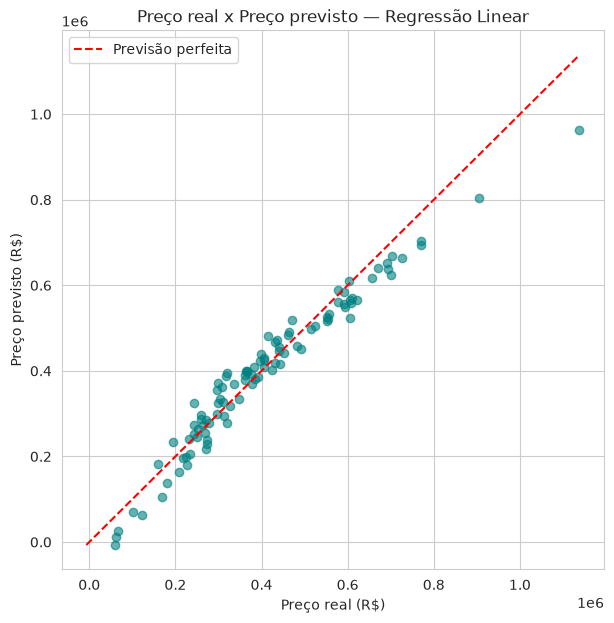

In [17]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, previsoes_final, alpha=0.6, color="teal")
limite_min = min(y_test.min(), previsoes_final.min())
limite_max = max(y_test.max(), previsoes_final.max())
plt.plot([limite_min, limite_max], [limite_min, limite_max], "r--", label="Previsão perfeita")
plt.xlabel("Preço real (R$)")
plt.ylabel("Preço previsto (R$)")
plt.title(f"Preço real x Preço previsto — {nome_modelo_final}")
plt.legend()
plt.show()

### Importância / coeficientes das variáveis (modelo final)

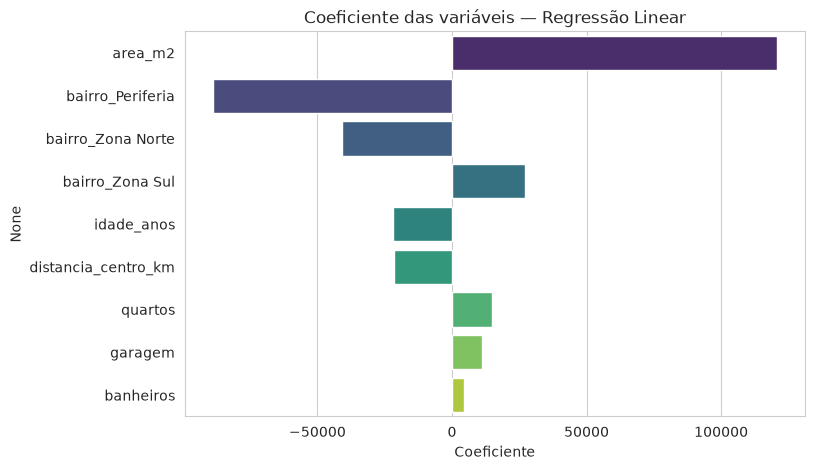

area_m2                120633.273495
bairro_Periferia       -88779.052126
bairro_Zona Norte      -40767.771258
bairro_Zona Sul         27117.997083
idade_anos             -22013.652828
distancia_centro_km    -21403.454133
quartos                 15000.738584
garagem                 11123.864622
banheiros                4468.821906
dtype: float64

In [18]:
if hasattr(modelo_final, "feature_importances_"):
    importancias = pd.Series(modelo_final.feature_importances_, index=X.columns).sort_values(ascending=False)
    eixo_x = "Importância"
else:
    importancias = pd.Series(modelo_final.coef_, index=X.columns).sort_values(key=abs, ascending=False)
    eixo_x = "Coeficiente"

plt.figure(figsize=(8, 5))
sns.barplot(x=importancias.values, y=importancias.index, hue=importancias.index, palette="viridis", legend=False)
plt.title(f"{eixo_x} das variáveis — {nome_modelo_final}")
plt.xlabel(eixo_x)
plt.show()

importancias

## 7️⃣ Etapa 6 — Testando o Modelo com Imóveis Novos

Agora vamos simular **imóveis novos** (que o modelo nunca viu) e usar o modelo final para prever o preço de cada um deles. É assim que o modelo seria usado na prática.

In [19]:
imoveis_novos = pd.DataFrame({
    "area_m2": [45, 80, 120, 200, 65],
    "quartos": [1, 2, 3, 4, 2],
    "banheiros": [1, 1, 2, 3, 1],
    "idade_anos": [2, 10, 5, 0, 20],
    "distancia_centro_km": [3.0, 8.5, 2.0, 1.0, 15.0],
    "garagem": [0, 1, 1, 1, 0],
    "bairro": ["Centro", "Zona Norte", "Zona Sul", "Zona Sul", "Periferia"],
})

# Aplicando a mesma transformação (one-hot encoding) usada no treinamento
imoveis_novos_proc = pd.get_dummies(imoveis_novos, columns=["bairro"], drop_first=True)

# Garantindo que as colunas fiquem na mesma ordem/formato do X de treino
imoveis_novos_proc = imoveis_novos_proc.reindex(columns=X.columns, fill_value=0)

# Se o modelo final for a Regressão Linear, precisamos padronizar os dados novos com o mesmo 'scaler'
if nome_modelo_final == "Regressão Linear":
    entrada_novos = scaler.transform(imoveis_novos_proc)
else:
    entrada_novos = imoveis_novos_proc

imoveis_novos["preco_previsto"] = modelo_final.predict(entrada_novos).round(2)
imoveis_novos

,area_m2,quartos,banheiros,idade_anos,distancia_centro_km,garagem,bairro,preco_previsto
0,45,1,1,2,3.0,0,Centro,290092.55
1,80,2,1,10,8.5,1,Zona Norte,346178.02
2,120,3,2,5,2.0,1,Zona Sul,715845.11
3,200,4,3,0,1.0,1,Zona Sul,1077863.32
4,65,2,1,20,15.0,0,Periferia,112443.40


## 8️⃣ Etapa 7 — Criando a Planilha de Previsões

Por fim, vamos gerar uma **planilha Excel (.xlsx)** com duas abas:

1. **Previsoes_Teste** — comparação entre o preço real e o preço previsto para os imóveis do conjunto de teste.
2. **Imoveis_Novos** — previsões para os imóveis novos simulados na etapa anterior.

Essa planilha pode ser aberta no Excel, Google Sheets, LibreOffice, etc.

In [20]:
# Montando a planilha com os resultados do conjunto de teste
tabela_teste = X_test.copy()
tabela_teste["preco_real"] = y_test.values
tabela_teste["preco_previsto"] = previsoes_final.round(2)
tabela_teste["diferenca_absoluta"] = (tabela_teste["preco_real"] - tabela_teste["preco_previsto"]).abs().round(2)
tabela_teste = tabela_teste.reset_index(drop=True)

nome_arquivo = "previsoes_precos_imoveis.xlsx"

with pd.ExcelWriter(nome_arquivo, engine="openpyxl") as writer:
    tabela_teste.to_excel(writer, sheet_name="Previsoes_Teste", index=False)
    imoveis_novos.to_excel(writer, sheet_name="Imoveis_Novos", index=False)
    resultados.to_excel(writer, sheet_name="Metricas_Modelos", index=False)

print(f"Planilha '{nome_arquivo}' criada com sucesso!")
tabela_teste.head()

Planilha 'previsoes_precos_imoveis.xlsx' criada com sucesso!


,area_m2,quartos,banheiros,idade_anos,distancia_centro_km,garagem,bairro_Periferia,bairro_Zona Norte,bairro_Zona Sul,preco_real,preco_previsto,diferenca_absoluta
0,136.0,3,1,3,1.72,0,False,False,False,770066.74,695134.45,74932.29
1,136.9,1,1,32,6.20,1,False,False,False,700397.09,624872.67,75524.42
2,154.6,2,2,15,1.59,0,False,False,True,906096.83,804955.85,101140.98
3,68.6,2,1,14,23.29,1,False,True,False,249970.09,246496.36,3473.73
4,85.2,1,2,19,6.20,1,False,False,False,453119.98,441640.11,11479.87


## ✅ Conclusão

Neste notebook percorremos **todas as etapas de um projeto de Ciência de Dados**:

1. Coleta de dados
2. Análise Exploratória de Dados (EDA)
3. Pré-processamento (tratamento e transformação dos dados)
4. Modelagem (treinamento de dois modelos diferentes)
5. Avaliação e comparação dos modelos
6. Teste com dados novos (simulando o uso real do modelo)
7. Exportação de uma planilha de previsões (`previsoes_precos_imoveis.xlsx`)

### 🚀 Próximos passos para continuar aprendendo

- Trocar o dataset sintético por um **dataset real** (ex: `pd.read_csv("seus_dados.csv")`).
- Testar outros algoritmos, como `GradientBoostingRegressor` ou `XGBoost`.
- Ajustar hiperparâmetros dos modelos com `GridSearchCV` ou `RandomizedSearchCV`.
- Fazer validação cruzada (`cross_val_score`) para uma avaliação mais robusta.
- Salvar o modelo treinado com `joblib` para reutilizá-lo depois sem retreinar.